In [1]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle


In [2]:
def privgen(data, dataset_name):

    # ENCODING
    encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, pickle_path='mappings.pkl', save=True)

    # GRID-SEARCH
    hyper_param_opt.hyper_param_search(
        encoded_data,
        percentage_outliers=0.1,
        dataset_name=dataset_name,
        top_n=10,
        eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
        min_samples_values=range(30, 50),
        save=True)

    # REMOVE DBSCAN OUTLIERS
    outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=33,
                                                            metric='euclidean', algorithm='auto',
                                                            leaf_size=50, dataset_name=dataset_name, plot=False)

    # GET DISTRIBUTIONS
    weighted_distance_calculation.calculate_plot_distance(dataset_name)

    # REMOVE DISTANT OUTLIERS

    threshold = {'0': 30000, '1': 30000, '2': 30000, '3': 30000, '4': 30000, '5': 15000,
                 '6': 21000, '7': 25000, '8': 12000, '9': 25000, '10': 20000, '11': 20000, '12': 22000}

    outlier_detection_by_dist.filter_and_save_by_distance(
        dataset_name, threshold, plot=False)

    # PLOT
    final_plot.plot_data_points(dataset_name)

    # DECODING

    decoded_data = data_encoder.ordinal_decode_categorical(dataset_name,
                                                           pickle_path='mappings.pkl')

    return decoded_data

In [3]:
data = pd.read_csv('../datasets/FAKE_People.csv')

Processing DBSCAN parameters: 100%|██████████| 21600/21600 [09:38<00:00, 37.34it/s] 


Percentage of outliers removed: 2.64%
Number of clusters found: 1


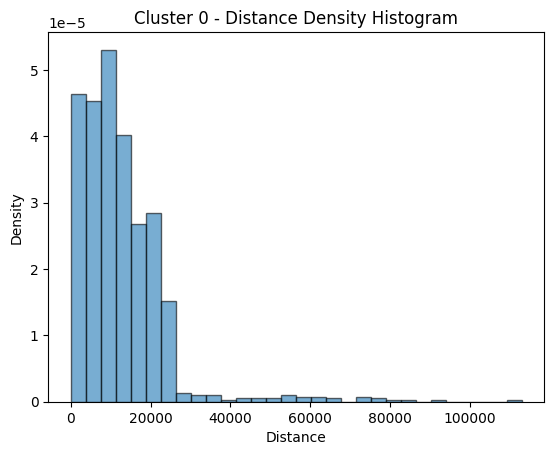

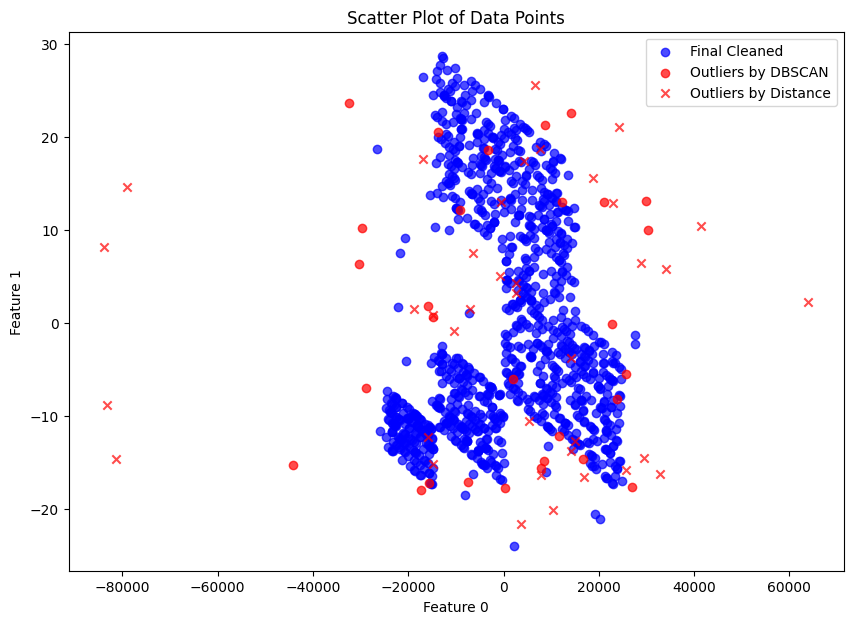

,Gender,Age,City,Salary
0,Non-binary,53,Venice,30561
1,Male,44,Venice,61456
2,Male,56,Venice,56645
3,Non-binary,56,Parma,52867
4,Female,57,Venice,52086
...,...,...,...,...
1029,Male,52,Venice,72271
1030,Male,49,Milan,35143
1031,Female,40,Parma,23011
1032,Female,35,Parma,50262


In [4]:
privgen(data, 'salary')

In [6]:
from synthcity.metrics import Metrics
from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader


In [40]:
# original dataset, with no change
orig = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/datasets/FAKE_People.csv')
X = orig.copy()
plugin = Plugins().get('tvae')
loader = GenericDataLoader(X, target_column="Salary",
                              sensitive_columns=["Age"])
plugin.fit(loader)
synth = plugin.generate(len(X), random_state=42).dataframe()

[2024-11-23T10:53:03.091417+0100][4140][CRITICAL] module disabled: /Users/navid/anaconda3/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
 50%|█████     | 500/1000 [01:14<01:14,  6.69it/s]


In [ ]:
score = Metrics.evaluate(
X_gt=loader.dataframe(),
X_syn=synth,
metrics={
'sanity': ['data_mismatch', 'common_rows_proportion', 'nearest_syn_neighbor_distance', 'close_values_probability', 'distant_values_probability'],
'stats': ['jensenshannon_dist', 'chi_squared_test', 'feature_corr', 'inv_kl_divergence', 'ks_test', 'max_mean_discrepancy', 'wasserstein_dist', 'prdc', 'alpha_precision', 'survival_km_distance'],
'performance': ['linear_model', 'mlp', 'xgb', 'feat_rank_distance'],
'detection': ['detection_xgb', 'detection_mlp', 'detection_gmm', 'detection_linear'],
'privacy': ['delta-presence', 'k-anonymization', 'k-map', 'distinct l-diversity', 'identifiability_score']
},
task_type='regression'
)

In [ ]:
score

,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
privacy.k-anonymization.gt,7,7,7.0,0.0,7.0,0.0,1,0,0.0,maximize
privacy.k-anonymization.syn,46.0,46.0,46.0,0.0,46.0,0.0,1,0,0.0,maximize
privacy.distinct l-diversity.gt,7,7,7.0,0.0,7.0,0.0,1,0,0.0,maximize
privacy.distinct l-diversity.syn,46.0,46.0,46.0,0.0,46.0,0.0,1,0,0.0,maximize


In [ ]:
# orig dataset, went through PrivGen
priv_orig = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/data/salary_8_decoded_data.csv')
X = priv_orig.copy()

plugin = Plugins().get('tvae')
loader = GenericDataLoader(X, target_column="Salary",
                              sensitive_columns=["Age"])
plugin.fit(loader)
synth = plugin.generate(len(X), random_state=42).dataframe()

[2024-11-23T10:45:06.454969+0100][4140][CRITICAL] module disabled: /Users/navid/anaconda3/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
 55%|█████▌    | 550/1000 [01:19<01:05,  6.91it/s]


In [ ]:
score = Metrics.evaluate(
X_gt=loader.dataframe(),
X_syn=synth,
metrics={
'sanity': ['data_mismatch', 'common_rows_proportion', 'nearest_syn_neighbor_distance', 'close_values_probability', 'distant_values_probability'],
'stats': ['jensenshannon_dist', 'chi_squared_test', 'feature_corr', 'inv_kl_divergence', 'ks_test', 'max_mean_discrepancy', 'wasserstein_dist', 'prdc', 'alpha_precision', 'survival_km_distance'],
'performance': ['linear_model', 'mlp', 'xgb', 'feat_rank_distance'],
'detection': ['detection_xgb', 'detection_mlp', 'detection_gmm', 'detection_linear'],
'privacy': ['delta-presence', 'k-anonymization', 'k-map', 'distinct l-diversity', 'identifiability_score']
},
task_type='regression'
)

In [27]:
score

,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
privacy.k-anonymization.gt,7,7,7.0,0.0,7.0,0.0,1,0,0.03,maximize
privacy.k-anonymization.syn,45.0,45.0,45.0,0.0,45.0,0.0,1,0,0.03,maximize
privacy.distinct l-diversity.gt,7,7,7.0,0.0,7.0,0.0,1,0,0.04,maximize
privacy.distinct l-diversity.syn,45.0,45.0,45.0,0.0,45.0,0.0,1,0,0.04,maximize


In [28]:
# orig dataset, went through PrivGen
priv_orig = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/data/salary_8_decoded_data.csv')
plugin = Plugins().get('dpgan')
X = priv_orig[priv_orig.columns[:-1]]
loader = GenericDataLoader(X, target_column="Salary")
plugin.fit(loader)
synth = plugin.generate(len(X), random_state=42).dataframe()

[2024-11-23T10:19:26.152947+0100][4140][CRITICAL] module disabled: /Users/navid/anaconda3/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
 15%|█▍        | 299/2000 [03:27<19:41,  1.44it/s]


In [29]:
score = Metrics.evaluate(
X_gt=orig.sample(len(synth)),
X_syn=synth,
metrics={
'sanity': ['data_mismatch', 'common_rows_proportion', 'nearest_syn_neighbor_distance', 'close_values_probability', 'distant_values_probability'],
'stats': ['jensenshannon_dist', 'chi_squared_test', 'feature_corr', 'inv_kl_divergence', 'ks_test', 'max_mean_discrepancy', 'wasserstein_dist', 'prdc', 'alpha_precision', 'survival_km_distance'],
'performance': ['linear_model', 'mlp', 'xgb', 'feat_rank_distance'],
'detection': ['detection_xgb', 'detection_mlp', 'detection_gmm', 'detection_linear'],
'privacy': ['delta-presence', 'k-anonymization', 'k-map', 'distinct l-diversity', 'identifiability_score']
},
task_type='regression'
)

In [30]:
score

,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
privacy.k-anonymization.gt,4,4,4.0,0.0,4.0,0.0,1,0,0.02,maximize
privacy.k-anonymization.syn,36.0,36.0,36.0,0.0,36.0,0.0,1,0,0.02,maximize
privacy.distinct l-diversity.gt,4,4,4.0,0.0,4.0,0.0,1,0,0.04,maximize
privacy.distinct l-diversity.syn,36.0,36.0,36.0,0.0,36.0,0.0,1,0,0.04,maximize


In [33]:
import pandas as pd
from pycanon import anonymity, report

FILE_NAME = "/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/data/salary_8_decoded_data.csv"
QI = ["Gender","Age","City"]
SA = ["Salary"]
DATA = pd.read_csv(FILE_NAME)

# Calculate k for k-anonymity:
k = anonymity.k_anonymity(DATA, QI)

# Print the anonymity report:
report.print_report(DATA, QI, SA)

c for (c,l)-diversity cannot be calculated as l=1
The dataset verifies:
          	 - k-anonymity with k = 1
          	 - (alpha,k)-anonymity with alpha = 1.0 and k = 1
          	 - l-diversity with l = 1
          	 - entropy l-diversity with l = 1
          	 - (c,l)-diversity with c = nan and l = 1
          	 - basic beta-likeness with beta = 1033.0
          	 - enhanced beta-likeness with beta = 6.9411900550683745
          	 - t-closeness with t = 0.5002460378444037
          	 - delta-disclosure privacy with delta = 6.9411900550683745


In [34]:
FILE_NAME = "/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/Privgen/datasets/FAKE_People.csv"
QI = ["Gender","Age","City"]
SA = ["Salary"]
DATA = pd.read_csv(FILE_NAME)

# Calculate k for k-anonymity:
k = anonymity.k_anonymity(DATA, QI)

# Print the anonymity report:
report.print_report(DATA, QI, SA)

c for (c,l)-diversity cannot be calculated as l=1
The dataset verifies:
          	 - k-anonymity with k = 1
          	 - (alpha,k)-anonymity with alpha = 1.0 and k = 1
          	 - l-diversity with l = 1
          	 - entropy l-diversity with l = 1
          	 - (c,l)-diversity with c = nan and l = 1
          	 - basic beta-likeness with beta = 1099.0
          	 - enhanced beta-likeness with beta = 7.003065458786462
          	 - t-closeness with t = 0.49951620989306755
          	 - delta-disclosure privacy with delta = 7.003065458786462


In [37]:

QI = ["Gender","Age","City"]
SA = ["Salary"]
DATA = synth

# Calculate k for k-anonymity:
k = anonymity.k_anonymity(DATA, QI)

# Print the anonymity report:
report.print_report(DATA, QI, SA)

ValueError: Values not defined: ['Salary']. Cannot be sensitive attributes

In [38]:
synth

,Gender,Age,City
0,Male,25,Venice
1,Male,41,Turin
2,Non-binary,58,Brescia
3,Non-binary,44,Milan
4,Non-binary,42,Verona
...,...,...,...
1029,Male,39,Padua
1030,Non-binary,38,Venice
1031,Male,22,Bologna
1032,Male,27,Parma
